Benötigte Module importieren und Datei laden. Die ersten Zeilen werden ausgegeben.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.utils import resample

path = "../Data/creditcard.csv"
data = pd.read_csv(path, delimiter=',')
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Time gibt die Sekunden zwischen der jeweiligen Transaktionen und der ersten an. Amount ist der Betrag, Class=1 bedeutet Betrug. V1 bis V8 sind verarbeitete Attribute ohne Beschreibung. Es sind 284807 Transaktionen gespeichert, davon 492 Betrugsfälle (0,173%).

Daten vorbereiten.

In [2]:
data_nfraud = data[data['Class']==0]
data_fraud = data[data['Class']==1]

print("data_fraud vor Upsampling", data_fraud.shape)
print("datan_fraud vor Upsampling", data_nfraud.shape)

data_fraud = resample(data_fraud, n_samples=data_nfraud.shape[0], random_state=42)

print("data_fraud nach Upsampling", data_fraud.shape)
print("datan_fraud nach Upsampling", data_nfraud.shape)
      
data = pd.concat([data_fraud, data_nfraud])
print("data nach Upsampling", data.shape)

data_fraud vor Upsampling (492, 31)
datan_fraud vor Upsampling (284315, 31)
data_fraud nach Upsampling (284315, 31)
datan_fraud nach Upsampling (284315, 31)
data nach Upsampling (568630, 31)


In [3]:
col = data['Class']

#data.drop(['Class'], axis = 1, inplace=True)
data.drop(['Class', 'Time'], axis = 1, inplace=True)

# Ausgabe der Verteilung
print(col.value_counts())

Class
1    284315
0    284315
Name: count, dtype: int64


Modell aufbauen, trainieren und testen

In [4]:
# Aus den zwei Tabellen vier Tabellen erzeugen
train_data, test_data, train_col, test_col = train_test_split(data,col, test_size=0.2, random_state=42)

xgb = XGBClassifier()

xgb.fit(train_data, train_col)
predicted_col = xgb.predict(test_data)

score = metrics.accuracy_score(test_col, predicted_col)
print(score)

0.9999384485517824


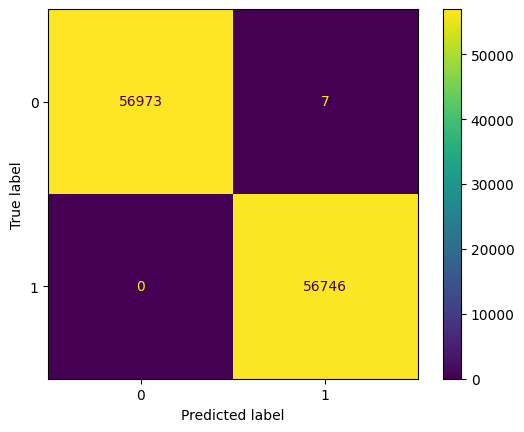

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_col, predicted_col)

disp = ConfusionMatrixDisplay(cm)

#print(test_col.shape)

disp.plot()